# Hazard Panel — Data Analysis
Loads the hazard panel, runs integrity checks, performs EDA on borrower
characteristics, then merges the macro panel and analyses macro-default relationships.

**Input:** `hazard_panel_full.parquet`, `macro_panel_quarterly.csv`
**Output:** `full_panel.parquet` (loan panel with macro columns merged in,
used by Model Development notebook for variable selection and model fitting)

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

## 2. Load Hazard Panel

In [2]:
df = pd.read_parquet('hazard_panel_full.parquet')

# Derive origination date and year from earliest observation per loan
orig = df.groupby('ID')['q'].min().rename('original_date')
df   = df.merge(orig, on='ID', how='left')
df['original_year'] = df['original_date'].dt.year

print(f'Rows:  {len(df):,}')
print(f'Loans: {df["ID"].nunique():,}')
df.head(3)

Rows:  54,229,735
Loans: 2,693,621


,ID,Date,UPB,Age,Rem,LTV,DTI,FICO,Delinq,t,q,default_in_q,first_default_q,q_next,target,original_date,original_year
0,100023274028,32000,0.00000,1.0,359.0,61.0,34.0,646.0,0.0,2000-03-01,2000-01-01,0,2002-07-01,2000-04-01,0,2000-01-01,2000
1,100023274028,62000,0.00000,4.0,356.0,61.0,34.0,646.0,0.0,2000-06-01,2000-04-01,0,2002-07-01,2000-07-01,0,2000-01-01,2000
2,100023274028,92000,129377.03125,7.0,353.0,61.0,34.0,646.0,0.0,2000-09-01,2000-07-01,0,2002-07-01,2000-10-01,0,2000-01-01,2000


## 3. Integrity Checks
Five checks that the hazard panel is correctly constructed.

In [3]:
print('1. Duplicate loan-quarter rows:')
print(f'   {df.duplicated(subset=["ID", "q"]).sum()}  (expect 0)\n')

print('2. Rows after first default quarter:')
bad = df[df['first_default_q'].notna() & (df['q'] > df['first_default_q'])]
print(f'   {len(bad)}  (expect 0)\n')

print('3. Loans with more than one target=1:')
multi = df.groupby('ID')['target'].sum()
print(f'   {(multi > 1).sum()}  (expect 0)\n')

print('4. Terminal rows with unobservable next-quarter outcome:')
terminal = df[df['q_next'] > df['q'].max()]
print(f'   {len(terminal):,}  -- will be dropped\n')

print('5. Target=1 rows not aligned with first_default_q:')
misplace = df[(df['target'] == 1) & (df['q_next'] != df['first_default_q'])]
print(f'   {len(misplace)}  (expect 0)')

1. Duplicate loan-quarter rows:
   0  (expect 0)

2. Rows after first default quarter:
   0  (expect 0)

3. Loans with more than one target=1:
   0  (expect 0)

4. Terminal rows with unobservable next-quarter outcome:
   30,199  -- will be dropped

5. Target=1 rows not aligned with first_default_q:
   0  (expect 0)


Terminal rows carry an unobservable next-quarter outcome — the model cannot
label them, so they are dropped before saving.

In [4]:
df = df[df['q_next'] <= df['q'].max()].copy()
print(f'Rows after dropping terminal observations: {len(df):,}')

Rows after dropping terminal observations: 54,199,536


## 4. Dataset Summary

In [5]:
loan_target = df.groupby('ID')['target'].sum()

print(f'Loans:                    {df["ID"].nunique():>12,}')
print(f'Loan-quarter rows:        {len(df):>12,}')
print(f'Defaulted loans:          {(loan_target == 1).sum():>12,}')
print(f'Never-defaulted loans:    {(loan_target == 0).sum():>12,}')
print(f'Avg rows per loan:        {df.groupby("ID").size().mean():>12.2f}')
print(f'Sample default rate:      {df["target"].mean()*100:>11.4f}%')
print(f'  (elevated due to case-control sampling -- not population rate)')

Loans:                       2,693,621
Loan-quarter rows:          54,199,536
Defaulted loans:             1,442,446
Never-defaulted loans:       1,251,175
Avg rows per loan:               20.12
Sample default rate:           2.6614%
  (elevated due to case-control sampling -- not population rate)


## 5. Default Rate Over Time

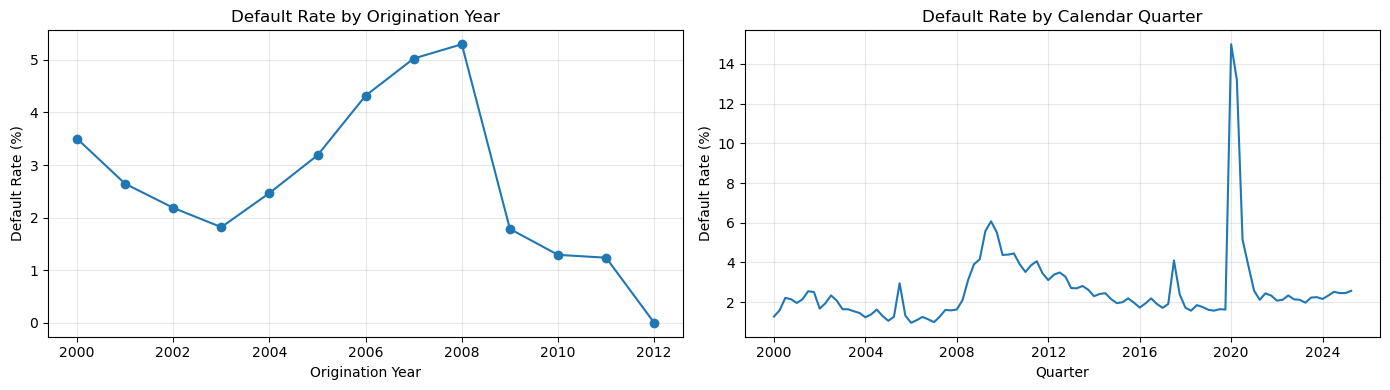

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# By origination year
orig_rate = df.groupby('original_year')['target'].mean().mul(100)
axes[0].plot(orig_rate.index, orig_rate.values, marker='o')
axes[0].set_title('Default Rate by Origination Year')
axes[0].set_xlabel('Origination Year')
axes[0].set_ylabel('Default Rate (%)')
axes[0].grid(True, alpha=0.3)

# By calendar quarter
cal_rate = df.groupby('q')['target'].mean().mul(100)
axes[1].plot(cal_rate.index, cal_rate.values, linewidth=1.5)
axes[1].set_title('Default Rate by Calendar Quarter')
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Default Rate (%)')
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 6. Default Hazard by Loan Age
The hazard profile should peak in the 2-5 year (8-20 quarter) seasoning window.

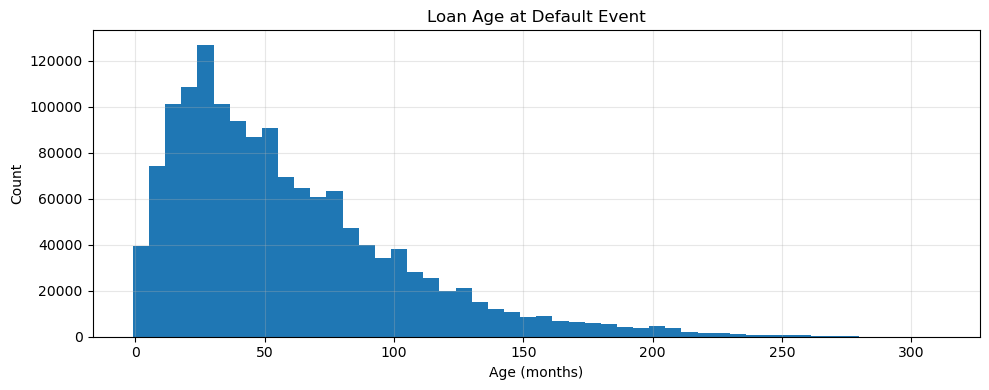

count    1.442446e+06
mean     5.858977e+01
std      4.405081e+01
min     -1.000000e+00
25%      2.500000e+01
50%      4.800000e+01
75%      8.000000e+01
max      3.110000e+02
Name: Age, dtype: float64


In [7]:
event_age = df.loc[df['target'] == 1, 'Age'].dropna()

plt.figure(figsize=(10, 4))
plt.hist(event_age, bins=50, edgecolor='none')
plt.title('Loan Age at Default Event')
plt.xlabel('Age (months)')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(event_age.describe())

## 7. Univariate Default Rate by Covariate
Expected relationships: default rate increases with LTV and DTI, decreases
with FICO, peaks at mid-seasoning for Age.

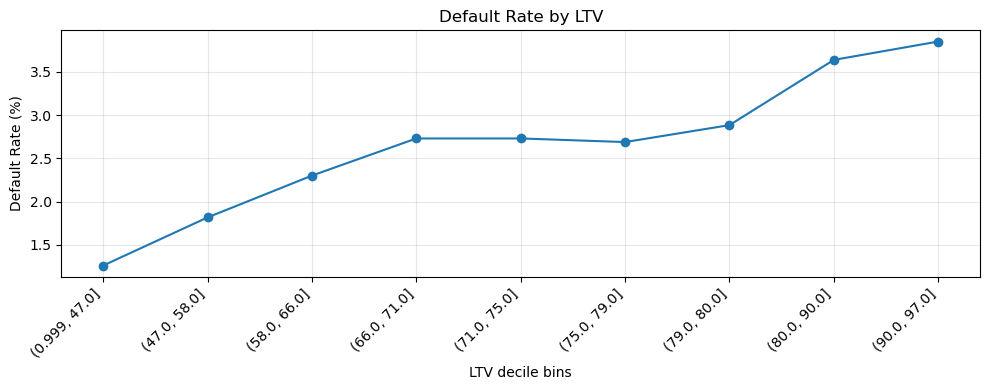

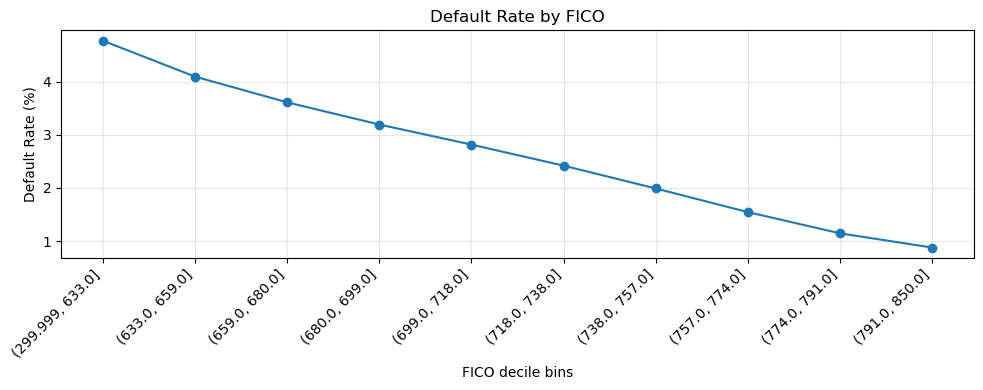

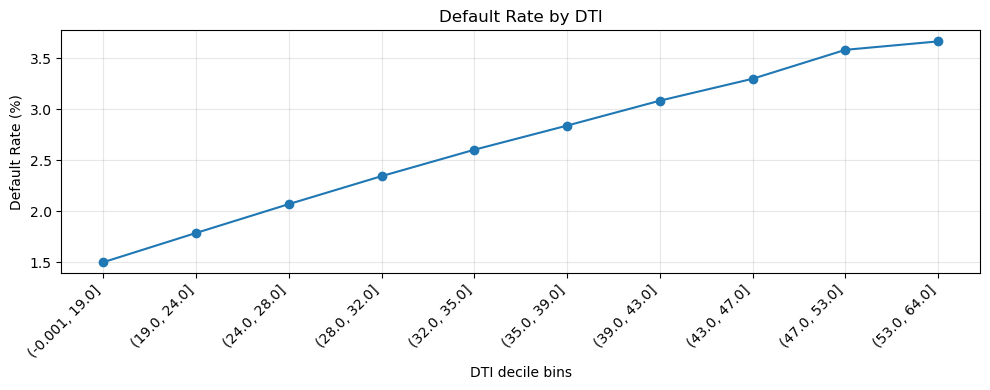

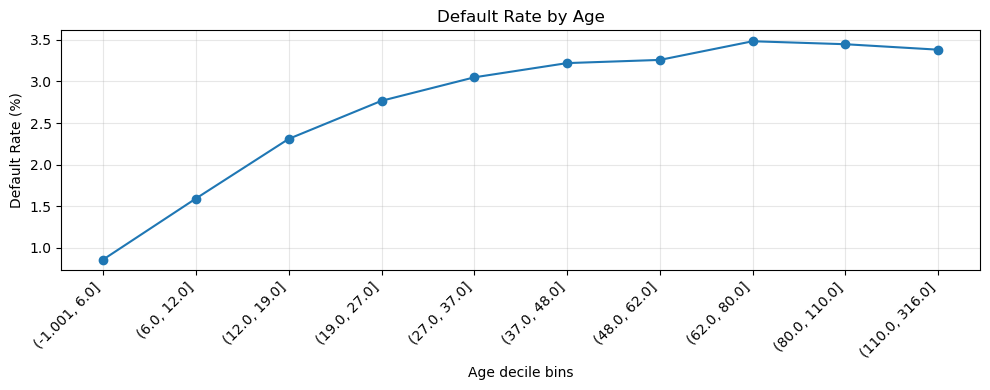

In [8]:
def plot_bad_rate(df, var, q=10):
    temp = df[[var, 'target']].dropna().copy()
    temp['bin'] = pd.qcut(temp[var], q=q, duplicates='drop')
    summary = (
        temp.groupby('bin', observed=False)['target']
            .agg(['mean', 'count'])
            .reset_index()
    )
    summary['mean'] *= 100

    plt.figure(figsize=(10, 4))
    plt.plot(range(len(summary)), summary['mean'], marker='o')
    plt.title(f'Default Rate by {var}')
    plt.xlabel(f'{var} decile bins')
    plt.ylabel('Default Rate (%)')
    plt.xticks(range(len(summary)), summary['bin'].astype(str),
               rotation=45, ha='right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


for v in ['LTV', 'FICO', 'DTI', 'Age']:
    plot_bad_rate(df, v)

## 8. Loan-Level Interaction Screening
Each panel shows how the relationship between X and default rate differs
across tertiles of G. Diverging lines indicate a meaningful interaction
worth testing in the PD model.

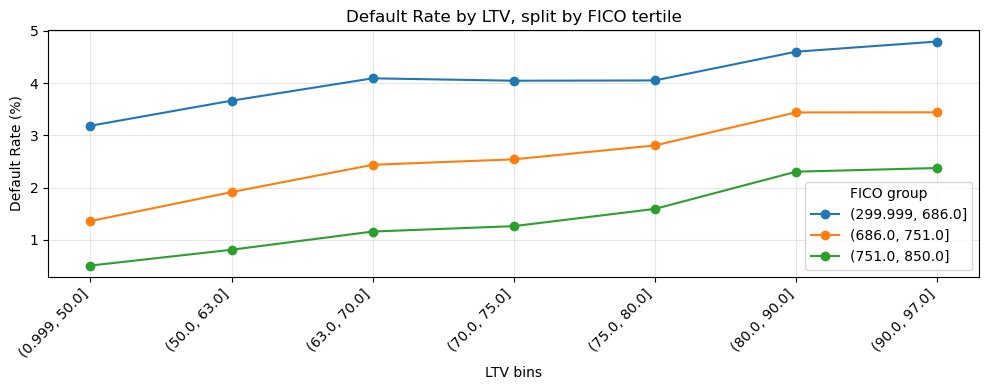

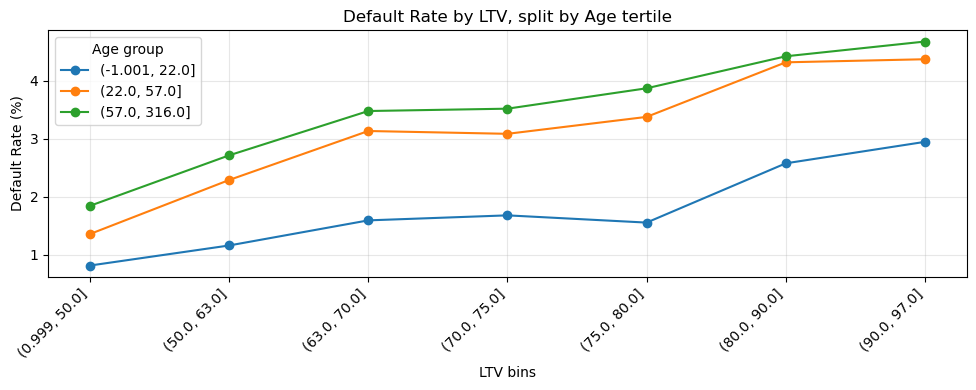

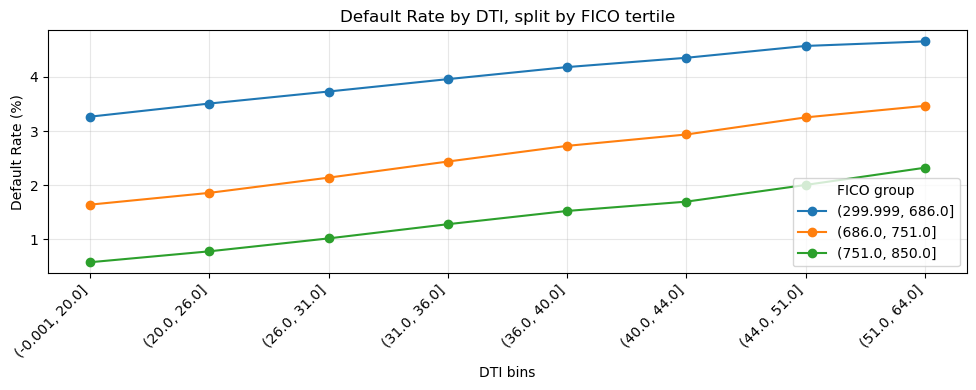

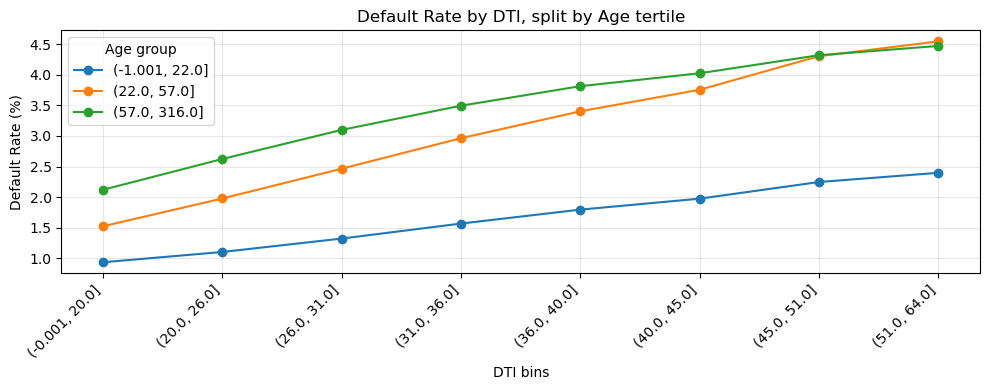

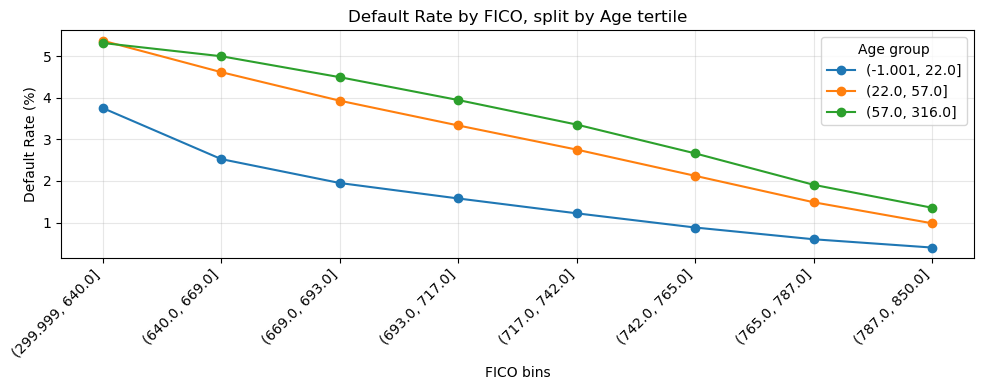

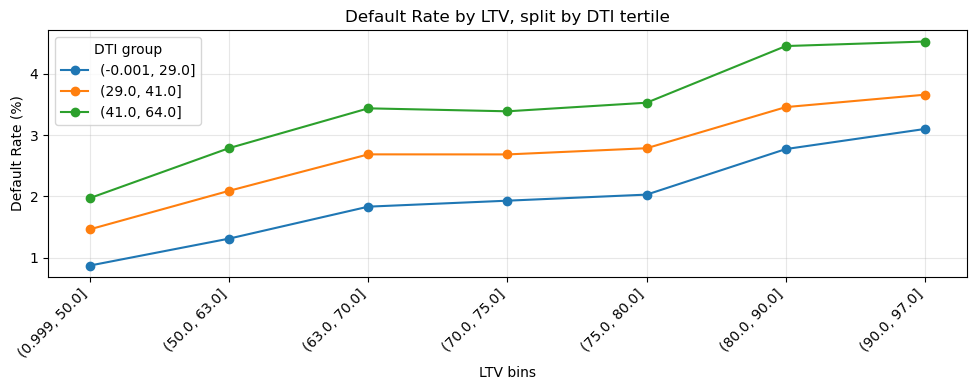

In [9]:
def plot_interaction(df, x_var, g_var, x_bins=8, g_bins=3):
    temp = df[[x_var, g_var, 'target']].dropna().copy()
    temp['x_bin'] = pd.qcut(temp[x_var], q=x_bins, duplicates='drop')
    temp['g_grp'] = pd.qcut(temp[g_var], q=g_bins, duplicates='drop')

    summary = (
        temp.groupby(['g_grp', 'x_bin'], observed=False)['target']
            .mean().mul(100).reset_index()
    )

    plt.figure(figsize=(10, 4))
    for grp, sub in summary.groupby('g_grp', observed=False):
        plt.plot(sub['x_bin'].astype(str), sub['target'],
                 marker='o', label=str(grp))
    plt.title(f'Default Rate by {x_var}, split by {g_var} tertile')
    plt.xlabel(f'{x_var} bins')
    plt.ylabel('Default Rate (%)')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title=f'{g_var} group')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


pairs = [
    ('LTV', 'FICO'), ('LTV', 'Age'), ('DTI', 'FICO'),
    ('DTI', 'Age'),  ('FICO', 'Age'), ('LTV', 'DTI'),
]
for x, g in pairs:
    plot_interaction(df, x, g)

## 9. Macro Analysis
Load the macro panel for correlation analysis and overlay plots.
The macro panel is kept separate and never fully merged into the loan panel
to avoid the memory cost of a 54M x 80 column matrix.

The Model Development notebook merges only the specific candidate columns
it needs at selection time.

In [10]:
macro = pd.read_csv(
    'macro_panel_quarterly.csv',
    index_col=0,
    parse_dates=True
)
macro.index.name = 'q'

print(f'Macro panel: {macro.shape[0]} quarters x {macro.shape[1]} columns')
print(f'Date range:  {macro.index.min().date()} to {macro.index.max().date()}')
print()

group_map = {
    'labour':       ['unemployment', 'payroll', 'labor_force', 'hourly'],
    'housing':      ['hpi', 'housing_start', 'building', 'months_supply'],
    'rates':        ['mortgage', 'treasury', 'fed_funds', 'prime', 'yield_curve'],
    'activity':     ['real_gdp', 'industrial', 'retail', 'consumer_sent'],
    'inflation':    ['cpi', 'pce', 'oer', 'rent', 'disp_income'],
    'credit':       ['hy_spread', 'bbb_spread', 'delinquency', 'networth', 'household_debt'],
    'demographics': ['working_age', 'population'],
}

def get_group(col):
    for grp, keywords in group_map.items():
        if any(kw in col for kw in keywords):
            return grp
    return 'other'

from collections import Counter
counts = Counter(get_group(c) for c in macro.columns)
for grp in ['labour','housing','rates','activity','inflation','credit','demographics','other']:
    if counts.get(grp, 0):
        print(f'  {grp:<15}: {counts[grp]} columns')

Macro panel: 427 quarters x 80 columns
Date range:  1919-01-01 to 2025-07-01

  labour         : 11 columns
  housing        : 14 columns
  rates          : 17 columns
  activity       : 10 columns
  inflation      : 13 columns
  credit         : 11 columns
  demographics   : 4 columns


In [11]:
# Merge only the calendar quarter default rate onto macro for analysis
# This is a 347-row join, not a 54M-row join
default_rate_q = df.groupby('q')['target'].mean().rename('default_rate')

macro_with_dr = macro.join(default_rate_q, how='inner')
print(f'Macro + default rate: {macro_with_dr.shape}')
print(f'Common quarters: {len(macro_with_dr)}')

Macro + default rate: (102, 81)
Common quarters: 102


## 10. Macro Correlation with Default Rate
Ranks every macro variable by its Pearson correlation with the quarterly
default rate. Use this as a first-pass signal for variable selection in
the Model Development notebook — high |correlation| + correct sign = good candidate.

Note: raw correlation with quarterly default rate is a univariate signal.
A variable that looks highly correlated here may lose significance once
loan characteristics (LTV, FICO, DTI) are controlled for. The AUC screen
in Model Development tests incremental lift conditional on loan features.

In [12]:
corrs = (
    macro_with_dr.drop(columns='default_rate')
                 .corrwith(macro_with_dr['default_rate'])
                 .rename('corr')
                 .to_frame()
)
corrs['abs_corr'] = corrs['corr'].abs()
corrs['group']    = corrs.index.map(get_group)
corrs = corrs.sort_values('abs_corr', ascending=False)

print('Top 20 macro variables by |correlation| with quarterly default rate:\n')
print(corrs.head(20)[['corr', 'abs_corr', 'group']].round(4).to_string())

Top 20 macro variables by |correlation| with quarterly default rate:

                                        corr  abs_corr         group
nonfarm_payrolls_log_growth_qoq      -0.5719    0.5719        labour
real_gdp_log_growth_yoy              -0.5403    0.5403      activity
labor_force_part_rate_qoq_change     -0.5308    0.5308        labour
nonfarm_payrolls_log_growth_yoy      -0.5194    0.5194        labour
unemployment_rate                     0.5124    0.5124        labour
unemployment_rate_yoy_change          0.5077    0.5077        labour
unemployment_rate_qoq_change          0.4898    0.4898        labour
labor_force_part_rate_yoy_change     -0.4773    0.4773        labour
real_gdp_log_growth_qoq              -0.4506    0.4506      activity
industrial_production_log_growth_yoy -0.4265    0.4265      activity
household_debt_log_growth_yoy        -0.4123    0.4123        credit
working_age_pop_log_growth_yoy       -0.3895    0.3895  demographics
treasury_10y                     

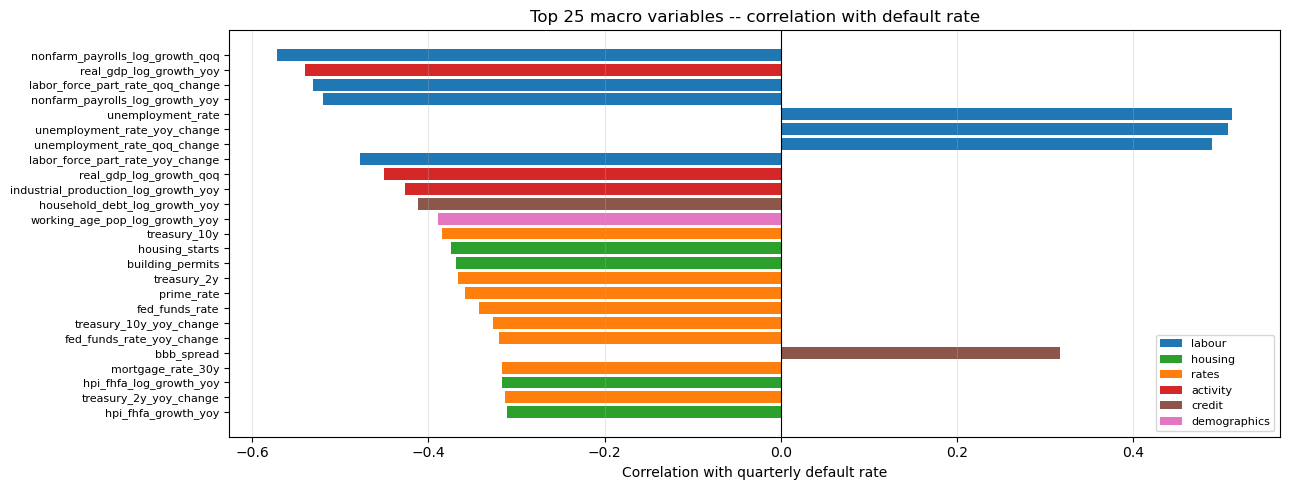

In [13]:
top25 = corrs.head(25).copy()
group_colours = {
    'labour':       'tab:blue',
    'housing':      'tab:green',
    'rates':        'tab:orange',
    'activity':     'tab:red',
    'inflation':    'tab:purple',
    'credit':       'tab:brown',
    'demographics': 'tab:pink',
    'other':        'tab:gray',
}
colours = top25['group'].map(group_colours).fillna('tab:gray')

fig, ax = plt.subplots(figsize=(13, 5))
ax.barh(range(len(top25)), top25['corr'].values, color=colours)
ax.set_yticks(range(len(top25)))
ax.set_yticklabels(top25.index, fontsize=8)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_xlabel('Correlation with quarterly default rate')
ax.set_title('Top 25 macro variables -- correlation with default rate')
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=c, label=g)
                for g, c in group_colours.items()
                if g in top25['group'].values]
ax.legend(handles=legend_elems, loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3, axis='x')
fig.tight_layout()
plt.show()

## 11. Macro Overlay Plots
Visual check that macro variables move in the expected direction relative
to the quarterly default rate.

PD model candidates:


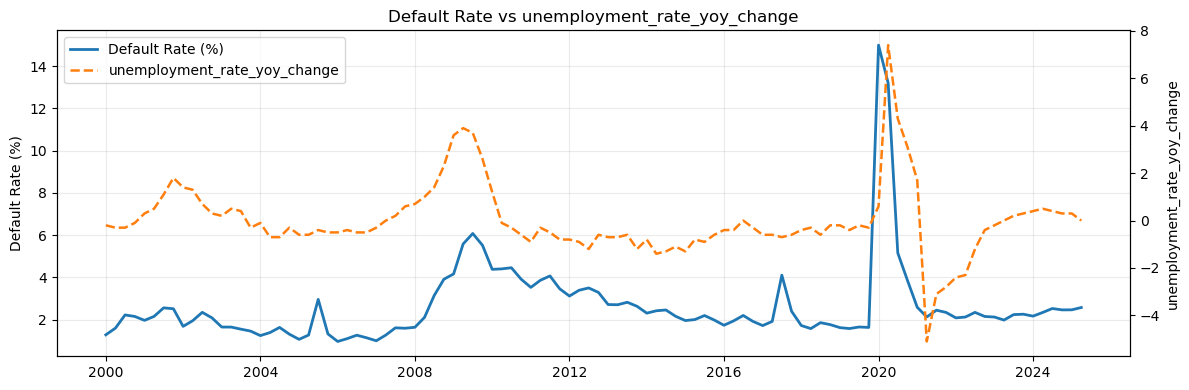

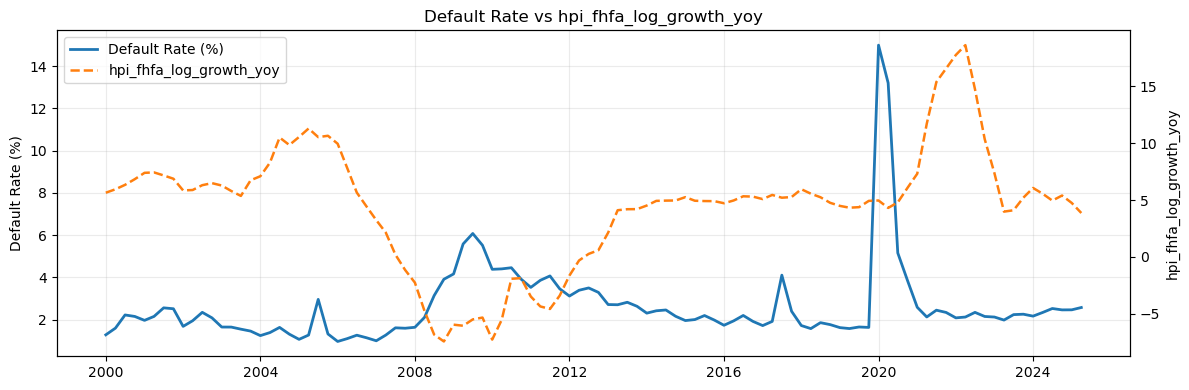

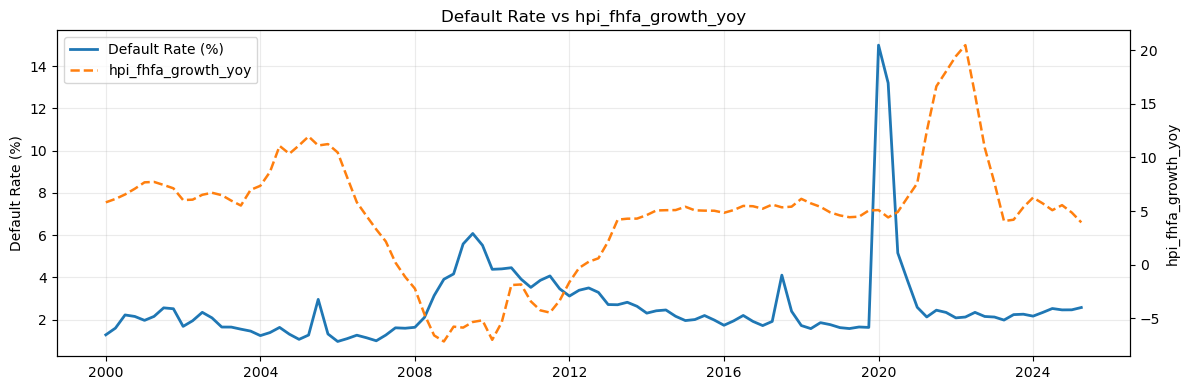

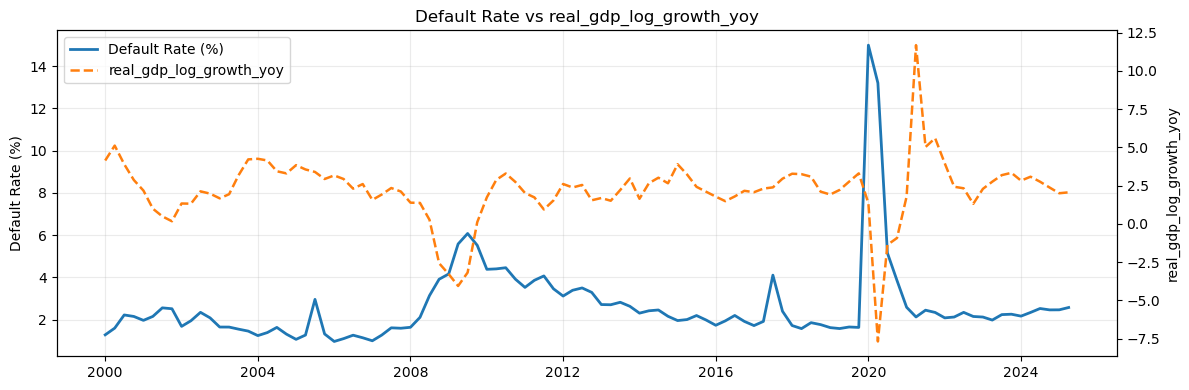

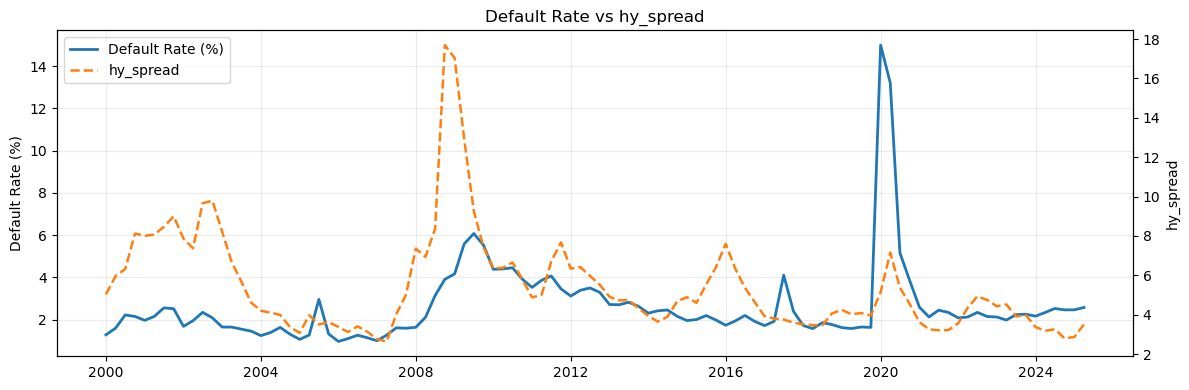

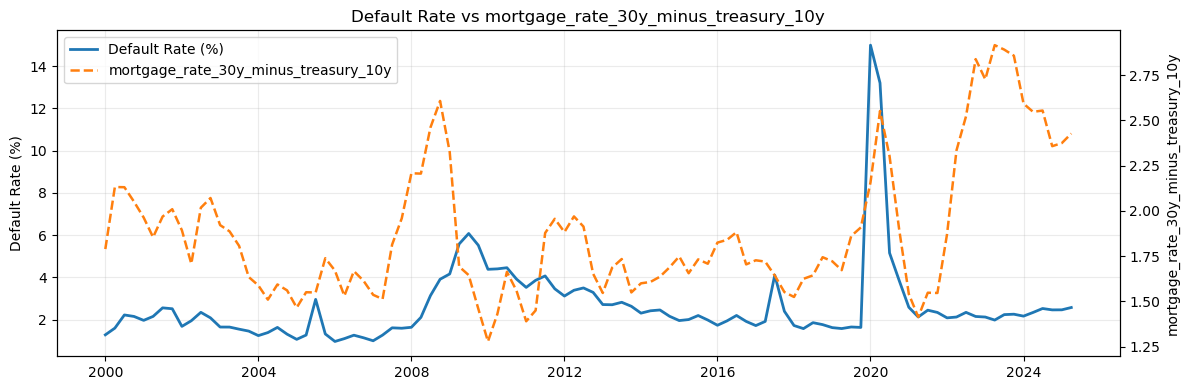

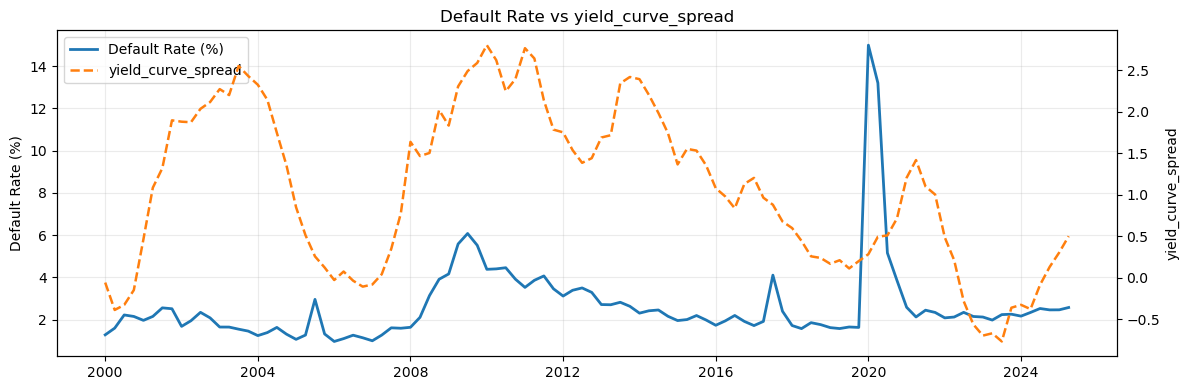

In [14]:
def plot_macro_overlay(macro_dr, macro_var, figsize=(12, 4)):
    if macro_var not in macro_dr.columns:
        print(f'  {macro_var}: not in panel, skipping')
        return

    plot_df = macro_dr[[macro_var, 'default_rate']].dropna().reset_index()
    plot_df['default_rate'] *= 100

    fig, ax1 = plt.subplots(figsize=figsize)
    l1 = ax1.plot(plot_df['q'], plot_df['default_rate'],
                  linewidth=2, label='Default Rate (%)')
    ax1.set_ylabel('Default Rate (%)')
    ax1.grid(True, alpha=0.25)

    ax2 = ax1.twinx()
    l2 = ax2.plot(plot_df['q'], plot_df[macro_var],
                  linewidth=1.8, linestyle='--', color='tab:orange',
                  label=macro_var)
    ax2.set_ylabel(macro_var)

    lines  = l1 + l2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left')
    plt.title(f'Default Rate vs {macro_var}')
    fig.tight_layout()
    plt.show()


pd_candidates = [
    'unemployment_rate_yoy_change',
    'hpi_fhfa_log_growth_yoy',
    'hpi_fhfa_growth_yoy',
    'real_gdp_log_growth_yoy',
    'hy_spread',
    'mortgage_rate_30y_minus_treasury_10y',
    'yield_curve_spread',
]

print('PD model candidates:')
for var in pd_candidates:
    plot_macro_overlay(macro_with_dr, var)

Additional top-correlated variables:


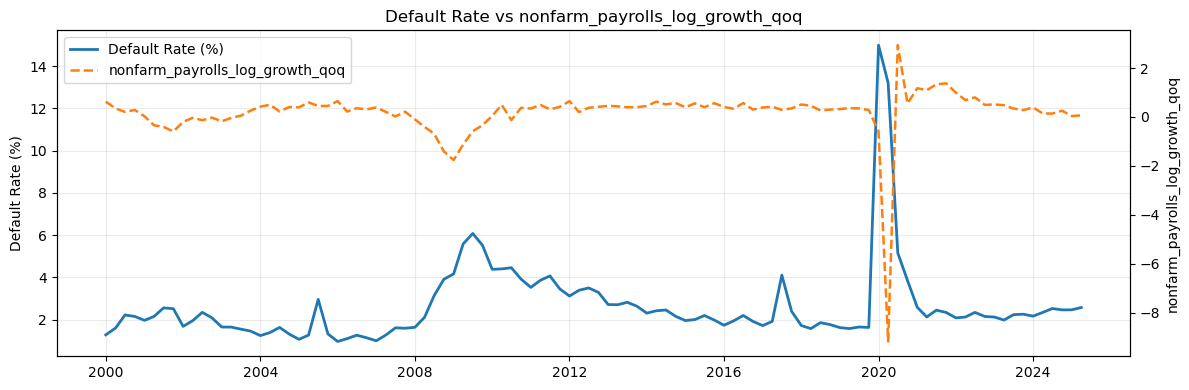

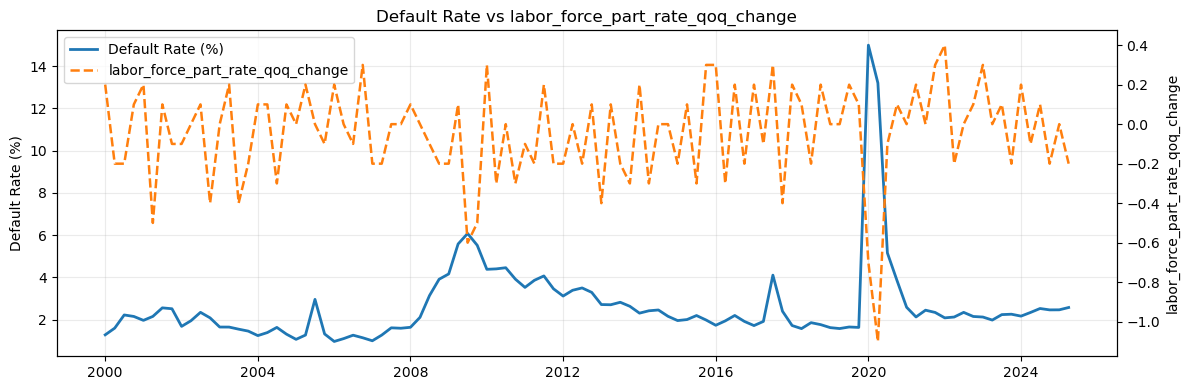

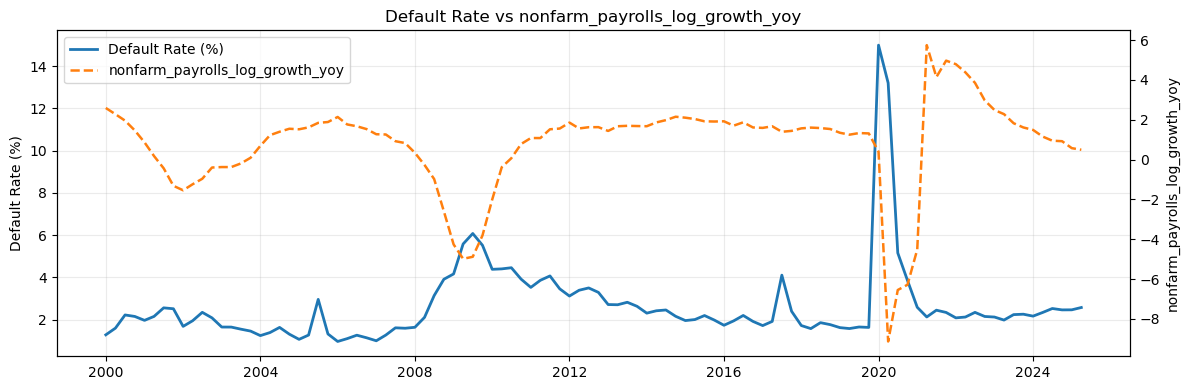

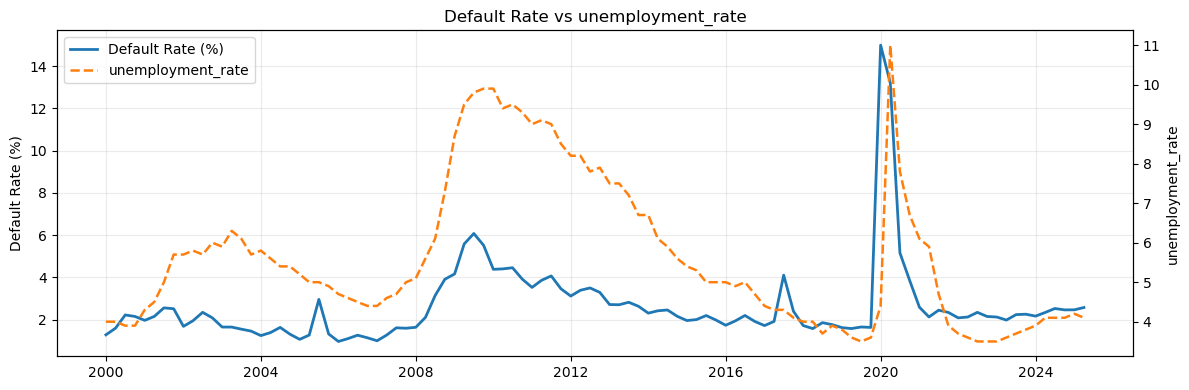

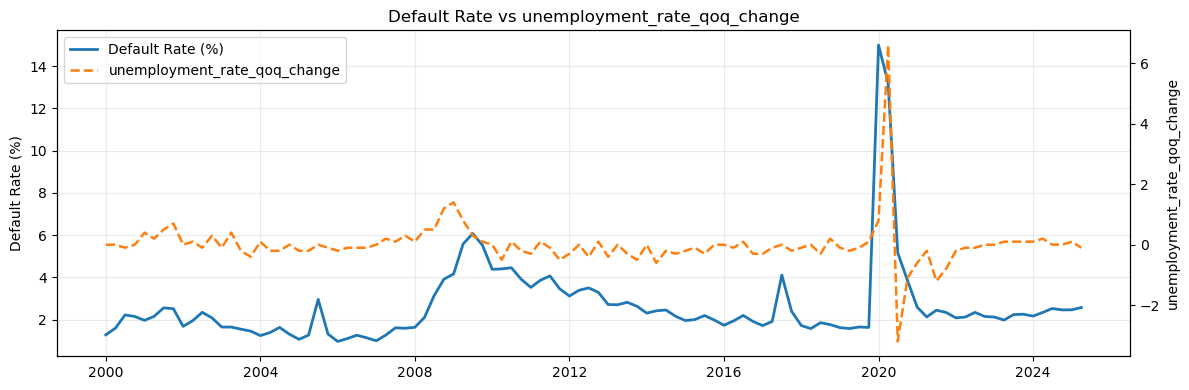

In [15]:
# Top 5 from correlation table not already plotted
already = set(pd_candidates)
top_extra = [v for v in corrs.head(10).index if v not in already][:5]

print('Additional top-correlated variables:')
for var in top_extra:
    plot_macro_overlay(macro_with_dr, var)

## 12. Macro-Loan Interaction Screening
Tests whether macro sensitivity varies by loan characteristic.
This merges only the two macro variables needed for the interaction plots
onto a sample of the loan panel — not the full 54M rows.

Sample for interaction plots: 2,709,977 rows


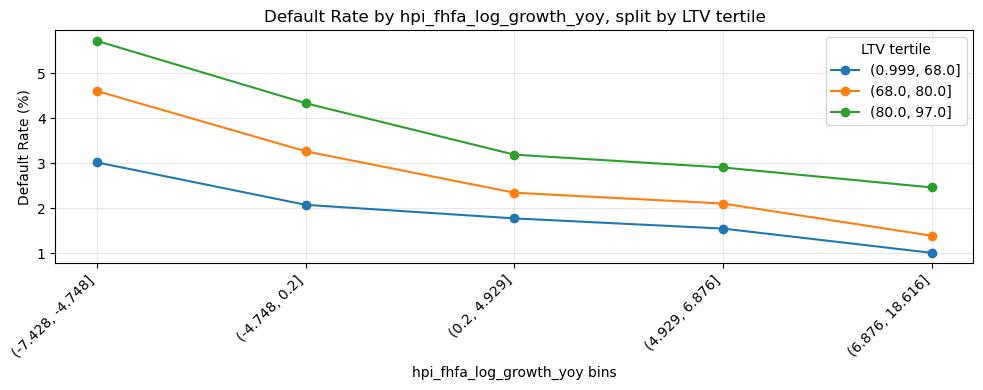

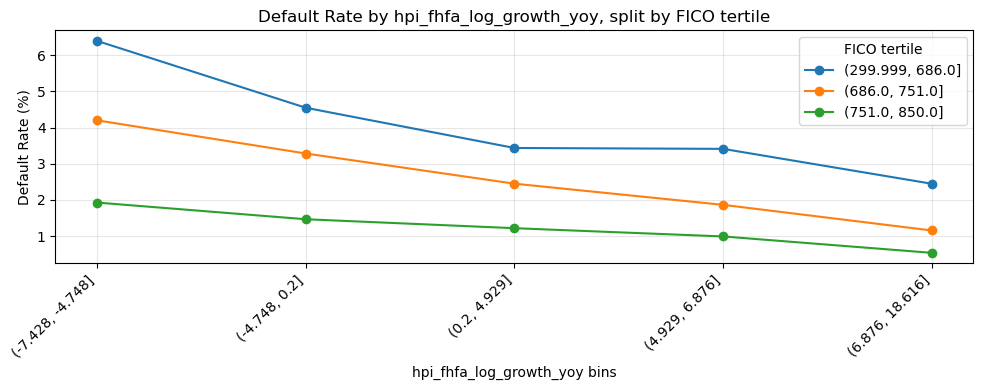

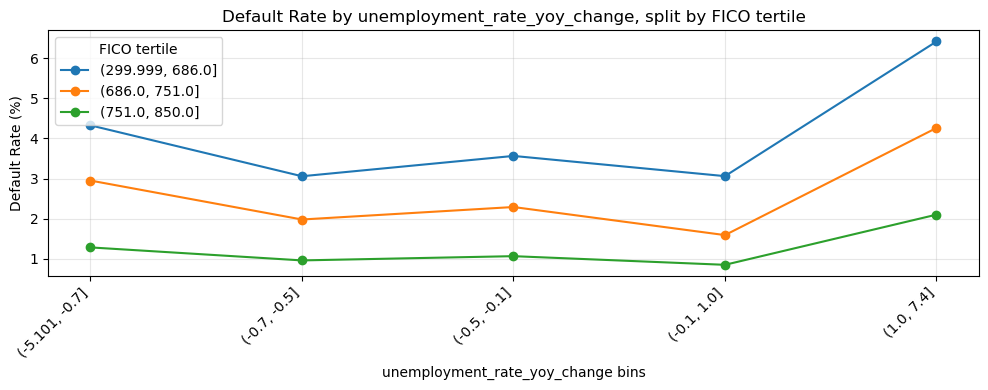

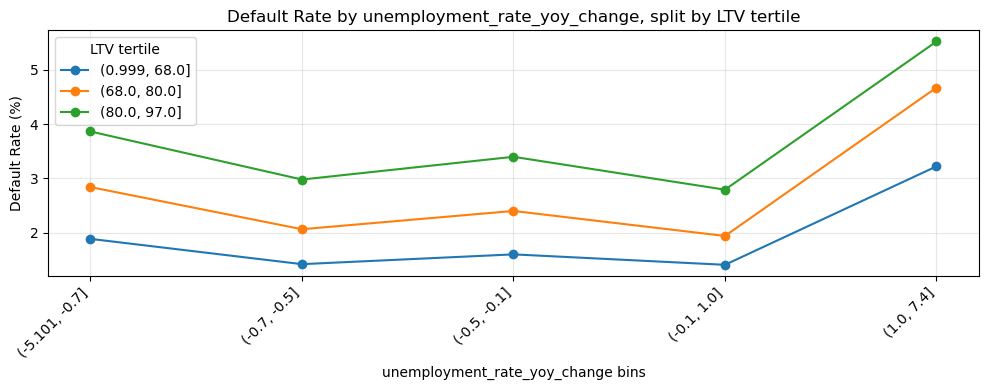

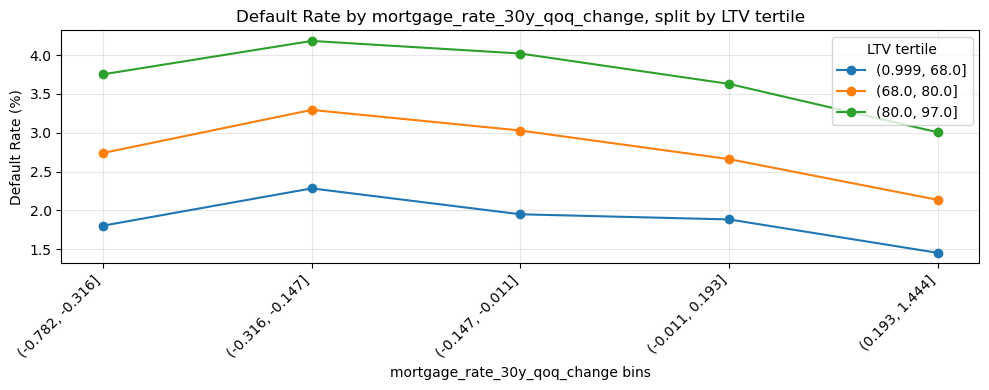

In [16]:
# Use a 5% sample of the loan panel for interaction plots
# Full panel is too large to hold with macro columns in memory
rng  = np.random.default_rng(42)
samp = df.sample(frac=0.05, random_state=42).copy()

# Merge only the two interaction variables
interaction_vars = [
    'hpi_fhfa_log_growth_yoy',
    'unemployment_rate_yoy_change',
    'mortgage_rate_30y_qoq_change',
]
available_ivars = [v for v in interaction_vars if v in macro.columns]

macro_small = macro[available_ivars].reset_index()
samp = samp.merge(macro_small, on='q', how='left')

print(f'Sample for interaction plots: {len(samp):,} rows')


def plot_macro_loan_interaction(df, macro_var, loan_var, macro_bins=5, loan_groups=3):
    if macro_var not in df.columns:
        print(f'  {macro_var}: not in sample, skipping')
        return

    temp = df[[macro_var, loan_var, 'target']].dropna().copy()
    temp['macro_bin']  = pd.qcut(temp[macro_var],  q=macro_bins,  duplicates='drop')
    temp['loan_group'] = pd.qcut(temp[loan_var],   q=loan_groups, duplicates='drop')

    summary = (
        temp.groupby(['loan_group', 'macro_bin'], observed=False)['target']
            .mean().mul(100).reset_index()
    )

    plt.figure(figsize=(10, 4))
    for grp, sub in summary.groupby('loan_group', observed=False):
        plt.plot(sub['macro_bin'].astype(str), sub['target'],
                 marker='o', label=str(grp))
    plt.title(f'Default Rate by {macro_var}, split by {loan_var} tertile')
    plt.xlabel(f'{macro_var} bins')
    plt.ylabel('Default Rate (%)')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title=f'{loan_var} tertile')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


macro_loan_pairs = [
    ('hpi_fhfa_log_growth_yoy',      'LTV'),
    ('hpi_fhfa_log_growth_yoy',      'FICO'),
    ('unemployment_rate_yoy_change', 'FICO'),
    ('unemployment_rate_yoy_change', 'LTV'),
    ('mortgage_rate_30y_qoq_change', 'LTV'),
]
for macro_var, loan_var in macro_loan_pairs:
    plot_macro_loan_interaction(samp, macro_var, loan_var)

## 13. Save Loan Panel
Saves `full_panel.parquet` containing only loan variables — no macro columns.
The Model Development notebook merges macro candidates on the fly during
variable selection, keeping memory usage manageable.

The macro panel path `macro_panel_quarterly.csv` is the source of truth
for all macro data in downstream notebooks.

In [17]:
# Drop any macro columns that were merged in during this session
# Keep only the original loan panel columns
loan_cols_only = [
    c for c in df.columns
    if c not in macro.columns
    or c == 'q'  # keep the join key
]
df_save = df[loan_cols_only].copy()

df_save.to_parquet('full_panel.parquet', index=False)

print(f'Saved: full_panel.parquet')
print(f'  Rows:    {len(df_save):,}')
print(f'  Columns: {df_save.shape[1]}')
print(f'  Loans:   {df_save["ID"].nunique():,}')
print()
print('Columns saved:')
for col in df_save.columns:
    print(f'  {col}')

Saved: full_panel.parquet
  Rows:    54,199,536
  Columns: 17
  Loans:   2,693,621

Columns saved:
  ID
  Date
  UPB
  Age
  Rem
  LTV
  DTI
  FICO
  Delinq
  t
  q
  default_in_q
  first_default_q
  q_next
  target
  original_date
  original_year
